# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
from cases.open_space.ngsolve_geometries import AnularDomain
from trefftz.dg.materials import Dielectric
R = 1.
r = 0.2


lc = 2.

eps_r = 16.

material = Dielectric(relative_permittivity=eps_r)


mesh = AnularDomain(R=R, r=r, scatterer_material = material, verbosity=0, Lc=lc, lc=lc)


In [2]:
from trefftz.dg.parameters import Elementwise
import numpy as np 

Regions = mesh.regions

refractive_index = Elementwise(mesh, {Regions.BACKGROUND: 1.,
                                      Regions.OMEGA: np.sqrt(material.eps_r)})


In [3]:
mesh.n_triangles

130

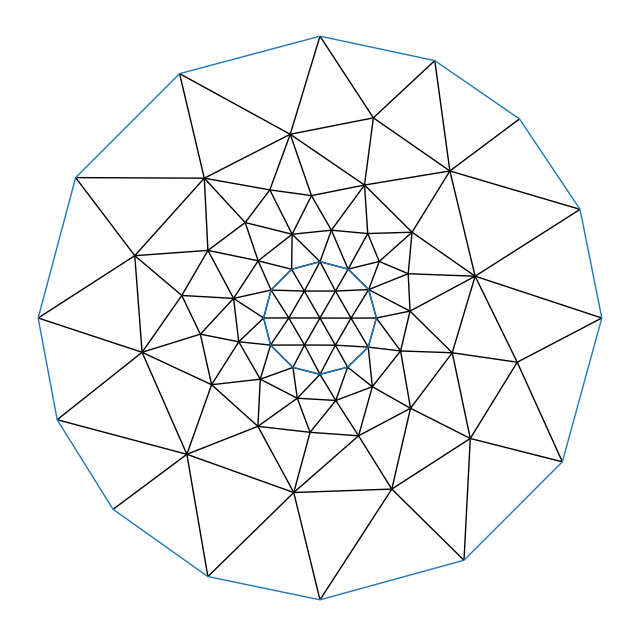

In [4]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

Text(0.5, 1.0, '$n=\\sqrt{\\varepsilon_\\mathrm{r}}$')

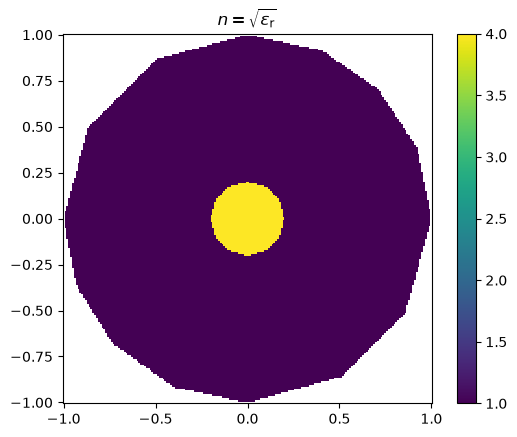

In [5]:
import matplotlib.pyplot as plt
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

Z = refractive_index(X, Y)

plt.pcolormesh(X, Y, Z)
plt.axis('square')
plt.colorbar()
plt.title('$n=\\sqrt{\\varepsilon_\\mathrm{r}}$')

In [6]:
Boundaries = mesh.boundaries
list(Boundaries)

[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

In [7]:
mesh.curve_boundaries([Boundaries.SIGMA, Boundaries.D_OMEGA], radius=[R, r])


bnd=<Boundaries.SIGMA: 'Sigma'>: edges=array([([ 0.        , -1.        ], [ 0.51102157, -0.85956789], [ 0.96425305,  0.26498312], [ 0.26498312, -0.96425305], [ 0.25551079, -0.92978394], 0.52996625,  True, -1, [22, -1]),
       ([ 0.51102157, -0.85956789], [ 0.85996246, -0.51035729], [ 0.70683356,  0.7073799 ], [ 0.7073799 , -0.70683356], [ 0.68549202, -0.68496259], 0.49366769,  True, -1, [56, -1]),
       ([ 1.        ,  0.        ], [ 0.85996246, -0.51035729], [-0.2646106 , -0.96435535], [ 0.96435535, -0.2646106 ], [ 0.92998123, -0.25517864], 0.52922119,  True, -1, [25, -1]),
       ([ 1.        ,  0.        ], [ 0.92273073,  0.38544521], [-0.19655696,  0.98049241], [ 0.98049241,  0.19655696], [ 0.96136536,  0.1927226 ], 0.39311391,  True, -1, [26, -1]),
       ([ 0.92273073,  0.38544521], [ 0.70783706,  0.70637575], [-0.55638393,  0.83092534], [ 0.83092534,  0.55638393], [ 0.81528389,  0.54591048], 0.3862327 ,  True, -1, [59, -1]),
       ([ 0.70783706,  0.70637575], [ 0.40726047,  

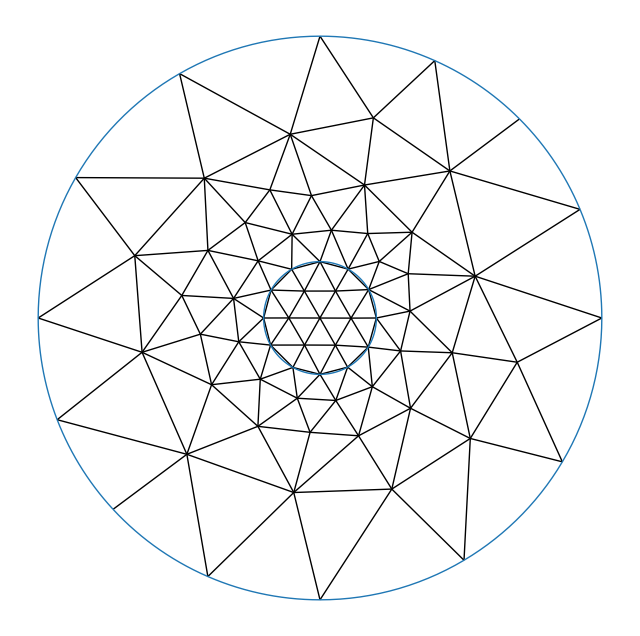

In [8]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [9]:
mesh.curved_boundaries

[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

In [10]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [11]:
import numpy as np
from trefftz.dg.exact import PlaneWave
theta_inc = np.pi
d_inc = np.array([np.cos(theta_inc), np.sin(theta_inc)])
data = PlaneWave(d=d_inc, A=1.)
boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=data), Boundaries.D_OMEGA: DirichletBC(data=None)}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [12]:
from trefftz.dg.block_fluxes import UltraWeakFlux, DirichletFlux

as well as specific ones (for a circular NtD map):

In [13]:
from cases.open_space.block_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [14]:
from trefftz.dg.assemblers import BlockNumerics
NtD_modes = 15
a = 0.5
b = 0.5
d2 = 0.5
numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=None), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=data)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = data)})

We should also choose a local basis

In [30]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
Ntheta = 12
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, refractive_index=refractive_index, k=k, N_theta=Ntheta)

and an assembler:

In [31]:
basis.N_DOF

1560

In [32]:
from trefftz.dg.assemblers import BlockAssembler

assembler = BlockAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [33]:
assembler._regions_RHS_term

[<Boundaries.SIGMA: 'Sigma'>]

so we can set the problem:

In [34]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [35]:
P.assemble_LHS()

assembling local operators
region: Sigma


100%|██████████| 14/14 [00:00<00:00, 28.86edge/s]


region: d_Omega


Interior: 100%|██████████| 188/188 [00:00<00:00, 1252.84edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 14/14 [01:10<00:00,  5.01s/edge]


<COOrdinate sparse array of dtype 'complex128'
	with 140256 stored elements and shape (1560, 1560)>

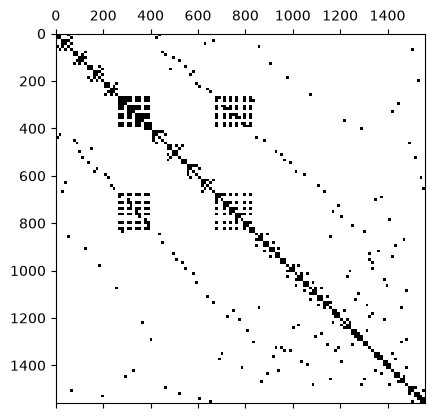

In [36]:
import matplotlib.pyplot as plt 
plt.spy(P.A.toarray())

In [37]:
P.assemble_RHS()

array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j], shape=(1560,))

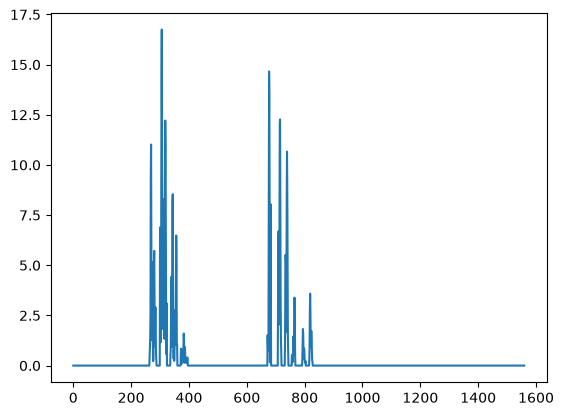

In [38]:
import numpy as np 
plt.plot(np.abs(P.b))

In [39]:
P.solve()

In [40]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[-8.97631810e+02+1.03013652e+03j,  1.47835623e+03+2.13336406e+02j,
        -8.38540571e+02-1.27260249e+03j, ...,
        -5.42903341e+02-5.63926175e+02j,  6.24383630e+02+7.36117562e+02j,
        -1.94170397e+02-1.16062962e+03j],
       [ 4.56054479e-01+3.89402056e-01j,  2.58688689e-01+1.25707151e-01j,
        -8.89958904e-02-1.79190451e-01j, ...,
         2.90880631e-01-4.09187585e-01j, -1.62627538e-01+1.96176781e-01j,
         2.20452935e-01+5.51840023e-01j],
       [ 6.41061069e+01+1.63999129e+01j, -1.86288764e+01-9.72570299e+01j,
        -2.84959387e+01+1.01565770e+02j, ...,
         9.91985167e+01-1.07159522e+02j, -8.46409906e+01+4.90939212e+00j,
         6.97391088e-01+4.83685963e+01j],
       ...,
       [ 2.71766721e-01+4.34680684e-01j, -2.05679427e-02+4.11122176e-01j,
         2.29214020e-02+2.17825404e-02j, ...,
         2.45099890e-01-3.36791338e-01j, -1.45795643e-02+1.83714386e-01j,
         2.98445384e-02+2.61960339e-01j],
       [ 2.37650329e-01+3.80233584e-01j,  2.

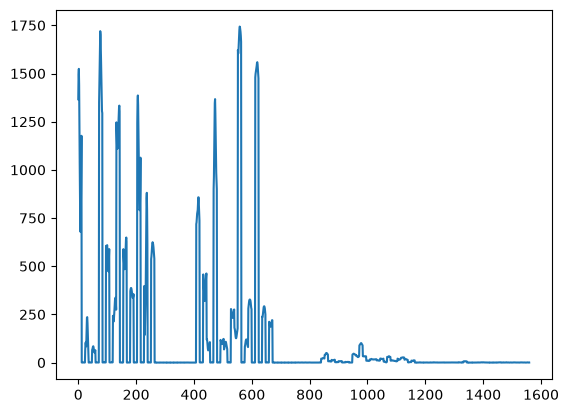

In [41]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

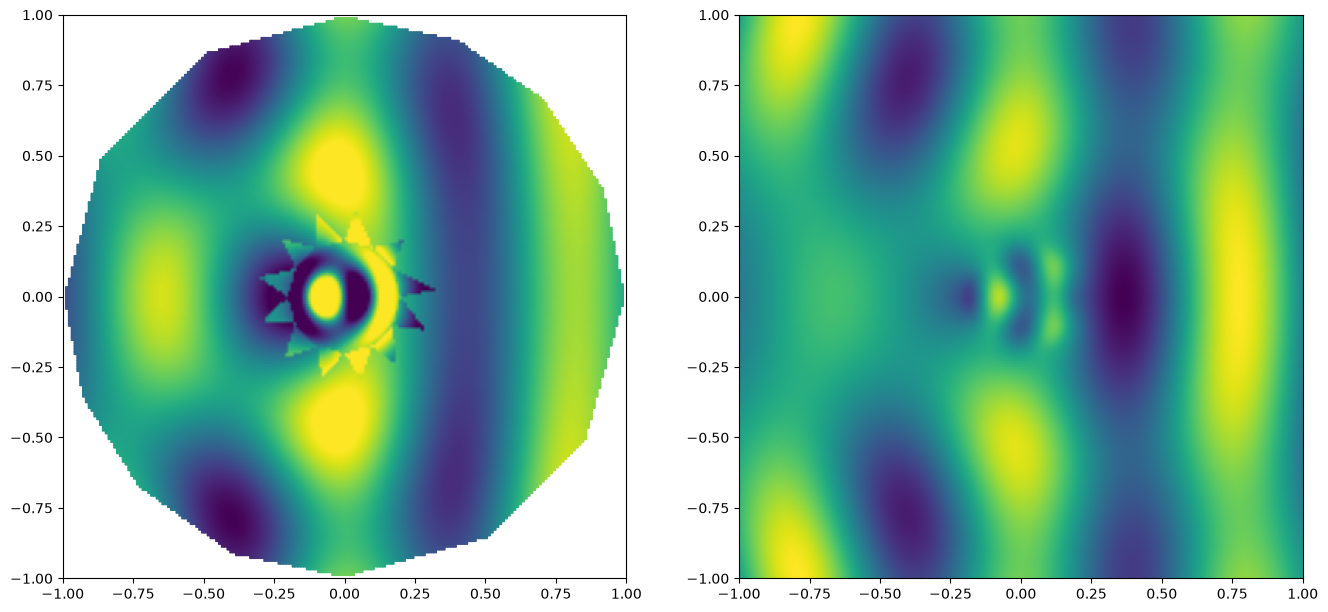

In [46]:
import matplotlib.pyplot as plt
from cases.open_space.exact import nf_diel_cylinder_plane_wave
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

U_h = P.u_h(X, Y)

U_s = nf_diel_cylinder_plane_wave(X, Y, k, theta_inc=np.pi, eps_r=eps_r, c=np.array([0., 0.]), R=r)
U_inc = np.exp(-1j*k*X)

RHO = np.sqrt(X**2 + Y**2)

U = np.where(RHO<r, U_s, U_s+U_inc)

fig, ax = plt.subplots(ncols=2, figsize=(16,8))
vmax = np.max(np.real(U))
vmin = np.min(np.real(U))

ax[0].pcolormesh(X, Y, np.real(U_h), vmin=vmin, vmax=vmax, shading="gouraud")
ax[0].axis('square')
ax[1].pcolormesh(X, Y, np.real(U), vmin=vmin, vmax=vmax, shading="gouraud")
ax[1].axis('square')


(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

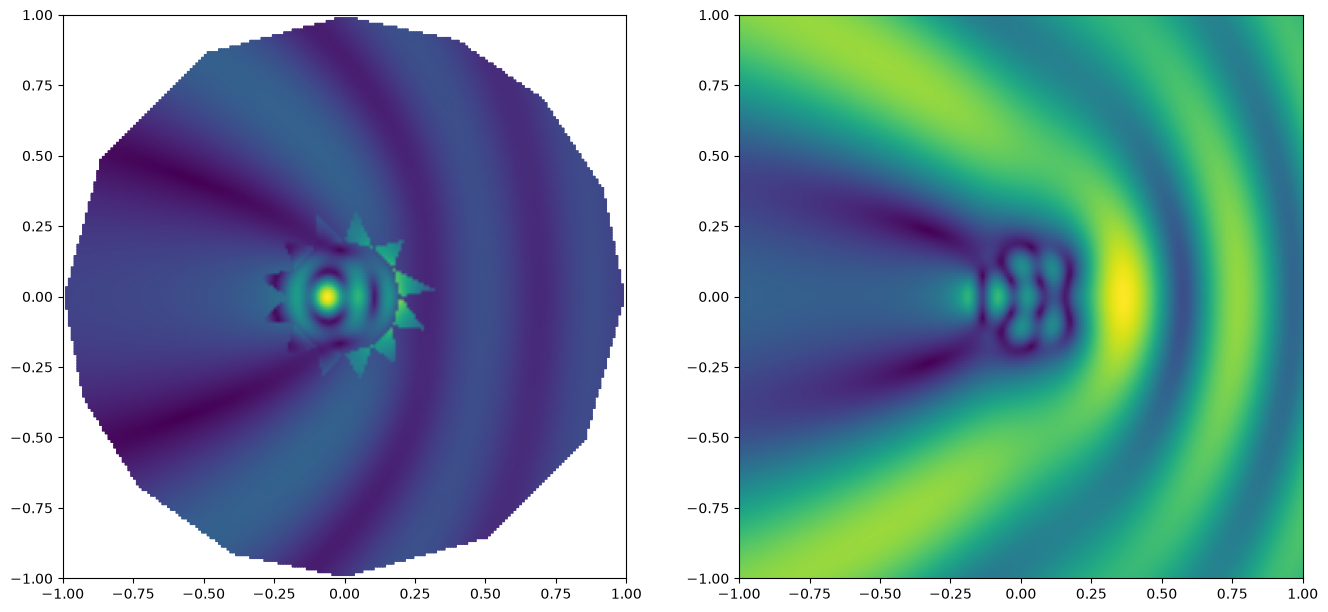

In [47]:
fig, ax = plt.subplots(ncols=2, figsize=(16,8))

ax[0].pcolormesh(X, Y, np.abs(U_h), shading="gouraud")
ax[0].axis('square')
ax[1].pcolormesh(X, Y, np.abs(U), shading="gouraud")
ax[1].axis('square')


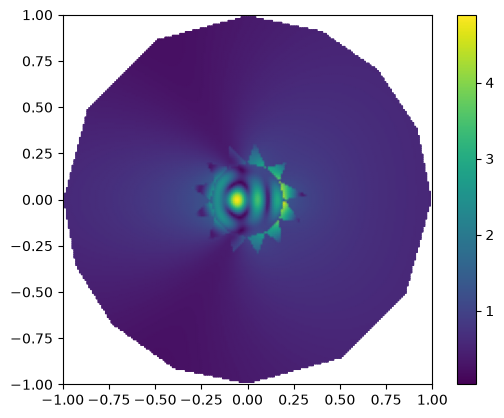

In [48]:
plt.pcolormesh(X, Y, np.abs(U_h - U), shading="gouraud")
plt.axis("square")
plt.colorbar()